In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patches
import sunpy
import sunpy.visualization
from sunpy.coordinates.spice import get_rotation_matrix
from sunpy.coordinates import propagate_with_solar_surface
from astropy.io import fits 
from astropy.wcs import WCS
import astropy.constants as const
import astropy.units as u
from astropy.visualization import ImageNormalize
from ndcube import NDCube
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
import os
os.environ["SPICE_KERNEL_PATH"] = "/cluster/home/zhuyin/scripts/spice_kernel/"
from mag_reproject import hgs_local_to_heeq_cart
from copy import deepcopy
import pyvista as pv
import pandas as pd
import mhsxtrapy
from mhsxtrapy.plotting import plot_magnetogram, plot_field_3d

In [2]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [29]:
data_bz = np.load("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.npy").T
data_bx = np.load("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/SOTSP/sotsp_bx_hgs_cea_fullfov.npy").T
data_by = np.load("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/SOTSP/sotsp_by_hgs_cea_fullfov.npy").T

In [4]:
data_bz.shape

(536, 960)

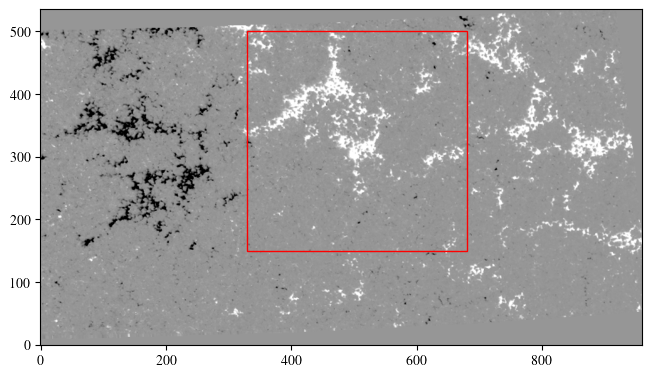

In [5]:
fig, ax = plt.subplots(layout="constrained")
ax.imshow(data_bz, aspect="equal", origin="lower", vmin=-500, vmax=500,
    cmap="Greys_r")

rect_sotsp = Rectangle((380-50, 200-50), 350, 350, linewidth=1, edgecolor="r", facecolor="none")
ax.add_patch(rect_sotsp)

In [3]:
fibril_tracing_dict = np.load("../../sav/fibril_tracing/Hbeta_mask_reconstructed_skel_res.npz")
fibril_tracing_dict.files

['mask',
 'skeleton',
 'straight_skeleton',
 'grouped_skeleton',
 'grouped_mask',
 'n_links',
 'Hbeta_Gand_image',
 'Hbeta_image',
 'Gband_image']

In [4]:
skel_ys, skel_xs = np.nonzero(fibril_tracing_dict["grouped_skeleton"][:])

In [5]:
def skeleton_orientation_pca(skel, window=5):
    """
    Compute orientation at each skeleton point using PCA on neighbors.
    Returns angles in [0, 180): 0 = vertical (top-down), 90 = horizontal, clockwise.
    """
    ys, xs = np.nonzero(skel)
    angles = np.full(skel.shape, np.nan)
    half = window // 2
    
    # Build a KD-tree-like lookup using the coordinate array
    coords = np.column_stack([ys, xs])
    
    for y, x in zip(ys, xs):
        # Get neighbors within a window
        mask = (np.abs(coords[:, 0] - y) <= half) & (np.abs(coords[:, 1] - x) <= half)
        nbrs = coords[mask]
        if len(nbrs) < 2:
            continue
        
        # PCA: principal direction = eigenvector of largest eigenvalue
        centered = nbrs - nbrs.mean(axis=0)
        cov = np.cov(centered.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        vy, vx = eigvecs[:, -1]  # largest eigenvalue's eigenvector (dy, dx)
        
        # Convert to your convention:
        # 0 = top-down (vertical), 90 = left-right (horizontal), clockwise
        # Standard math angle from +x axis: atan2(vy, vx) [note: image y is flipped]
        # We want angle from vertical, clockwise in image coords (y increases downward)
        ang = np.degrees(np.arctan2(vx, vy))   # angle from vertical axis
        ang = ang % 180                         # fold into [0, 180)
        angles[y, x] = ang
    
    return angles

In [6]:
def angle_between(skel_angle, vec_angle):
    """
    skel_angle: orientation in [0, 180), 180-ambiguous
    vec_angle: direction in [0, 360), fully directed
    Returns: angle between them in [0, 90]
    """
    diff = (vec_angle - skel_angle) % 180   # fold by 180 (skeleton symmetry)
    return np.minimum(diff, 180 - diff)     # fold by 90 (take acute angle)

In [7]:
skel_angle = skeleton_orientation_pca(fibril_tracing_dict["grouped_skeleton"])
skel_angle_ys, skel_angle_xs = np.nonzero(~np.isnan(skel_angle))
skel_angle_vals = skel_angle[skel_angle_ys, skel_angle_xs]

In [ ]:
# data_bz_crop = data_bz[150:150+350, 330:330+350]
data_bz_crop = data_bz

In [8]:

sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits")
# sotsp_br_map_crop = sotsp_br_map.submap(
#     bottom_left=(330, 150)*u.pix,
#     top_right=(330+350-1, 150+350-1)*u.pix
# )

sotsp_br_map_crop = sotsp_br_map

sotsp_br_map_crop_center_lon = -24.866559216955352 
sotsp_br_map_crop_center_lat = 16.31003568484626

sotsp_br_wcs_mod = deepcopy(sotsp_br_map_crop.wcs)
sotsp_br_wcs_mod.wcs.aux.rsun_ref = sotsp_br_wcs_mod.wcs.aux.rsun_ref + 4*0.23712652199468398e6

In [9]:
dkist_wcs_mod = deepcopy(dkist_vbi_target_cube_crop.wcs)
dkist_wcs_mod = unwrap_wcs_to_fitswcs(dkist_wcs_mod)[0]
dkist_wcs_mod.wcs.aux.rsun_ref = sotsp_br_wcs_mod.wcs.aux.rsun_ref

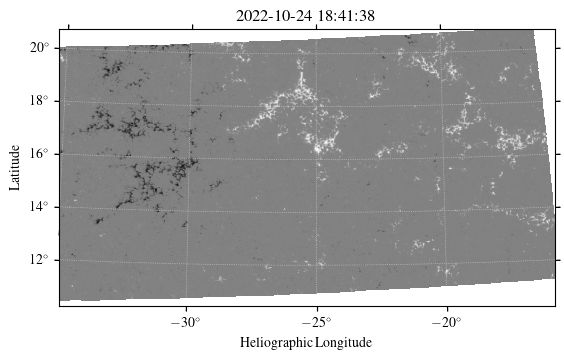

In [13]:
sotsp_br_map.plot()

In [38]:
data2d_test = mhsxtrapy.BoundaryData.from_array(np.nan_to_num(data_bz,0),
        pixel_size=0.23712652199468398, nz=536, pz=0.05)
data2d_test.bx = np.nan_to_num(data_bx,0)
data2d_test.by = np.nan_to_num(data_by,0)

In [39]:
mhsxtrapy.alpha_HS04(data2d_test)

np.float64(-0.005067820152033443)

In [10]:
def make_extrapolation(bz, alpha=0,a=0.05,return_full_res=False,save_dir=None):
    ny, nx = bz.shape
    nz = np.min((ny, nx)).astype(int)
    # xmin, xmax, ymin, ymax, zmin, zmax = 0.0, 1.0, 0.0, 1.0, 0.0, 1.0

    pixelsize_x = 0.23712652199468398
    pixelsize_y = pixelsize_x
    pixelsize_z = pixelsize_x

    x_arr = np.arange(nx) * pixelsize_x
    y_arr = np.arange(ny) * pixelsize_y
    z_arr = np.arange(nz) * pixelsize_z

    data2d = mhsxtrapy.BoundaryData.from_array(bz,
        pixel_size=pixelsize_x, nz=nz, pz=0.05)

    data3d = mhsxtrapy.extrapolate(data2d, alpha=alpha,
        a=a, b=1.0, which_solution=mhsxtrapy.WhichSolution.NADOL_NEUKIRCH,
        z0=2.0, deltaz=0.2)
    
    bx_extra = data3d.field[:,:,:,1]
    by_extra = data3d.field[:,:,:,0]
    bz_extra = data3d.field[:,:,:,2]

    bx_extra = bx_extra[ny:ny*2, nx:nx*2,:]
    by_extra = by_extra[ny:ny*2, nx:nx*2,:]
    bz_extra = bz_extra[ny:ny*2, nx:nx*2,:]

    if save_dir is not None:
        data3d.save(path=save_dir)

    if return_full_res:
        return bx_extra, by_extra, bz_extra, data3d
    else:
        return bx_extra, by_extra, bz_extra

In [15]:
bx_extra_test, by_extra_test, bz_extra_test, data3d_test = make_extrapolation(data_bz_crop, return_full_res=True)

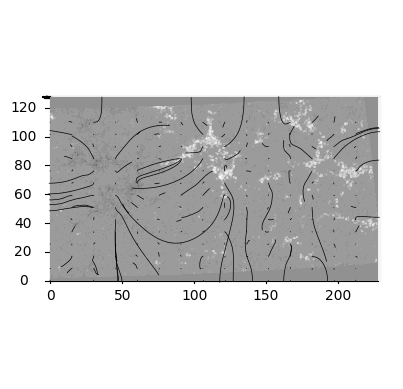

In [16]:
with plt.style.context("default"):
    fig, ax = plot_field_3d(data3d_test, view="los", footpoints="all", pixel_stride_x=10, pixel_stride_y=10)
    fig.show()

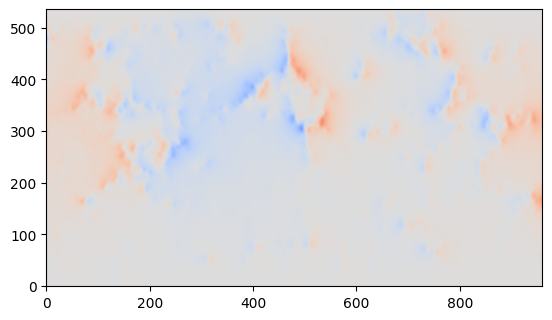

In [17]:
with plt.style.context("default"):
    plt.imshow(bx_extra_test[:,:,20], cmap="coolwarm", vmin=-500, vmax=500, origin="lower")

In [11]:
def draw_colorwheel(parent_ax, bbox=[0, 0, 0.22, 0.22], show_labels=True,
                    box_pad=0.01, box_facecolor='white', box_edgecolor='gray',
                    box_alpha=0.6, box_linewidth=0.8, corner_radius=0.02,
                    cmap='twilight_shifted'):
    n = 512
    theta = np.linspace(0, 2*np.pi, n)
    r = np.linspace(0., 1, n)
    T, R = np.meshgrid(theta, r)
    Z = T

    # Rounded background rectangle in parent-axes coordinates
    x0, y0, w, h = bbox
    rect = patches.FancyBboxPatch(
        (x0 - box_pad, y0 - box_pad),
        w + 2*box_pad, h + 2*box_pad,
        boxstyle=f"round,pad=0,rounding_size={corner_radius}",
        transform=parent_ax.transAxes,
        facecolor=box_facecolor, edgecolor=box_edgecolor,
        linewidth=box_linewidth, alpha=box_alpha,
        zorder=4, rasterized=True
    )
    parent_ax.add_patch(rect)

    ax = parent_ax.inset_axes(bbox, projection='polar')
    ax.set_zorder(5)

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    ax.pcolormesh(T, R, Z, cmap=cmap, shading='auto',
                  norm=ImageNormalize(vmin=0, vmax=2*np.pi),
                  edgecolors='none', linewidth=0,
                  rasterized=True)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)

    ax.spines['polar'].set_visible(False)
    ax.tick_params(which='both', length=0)
    ax.patch.set_alpha(0)

    if show_labels:
        ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
        ax.set_xticklabels(['0°', '90°', '180°', '270°'], fontsize=8)
    else:
        ax.set_xticklabels([])
    
    return ax

In [12]:
def calc_sep_angle_dist(bx_extra, by_extra, bz_extra,
    lon=sotsp_br_map_crop_center_lon, lat=sotsp_br_map_crop_center_lat,
    dateobs=sotsp_br_map.date.isot, map_wcs=sotsp_br_wcs_mod,
    dkist_wcs=dkist_wcs_mod,skel_angles=skel_angle,
    skel_angle_xs=skel_angle_xs, skel_angle_ys=skel_angle_ys,
    debug=False, xlim=None, ylim=None,
    height_index=20):

    bx_heeq, by_heeq, bz_heeq = hgs_local_to_heeq_cart(
        bx_extra.transpose(1,0,2),
        by_extra.transpose(1,0,2),
        bz_extra.transpose(1,0,2),
        lon, lat
    )

    rotation_matrix = get_rotation_matrix("SUN_EARTH_CEQU", "EARTH_SOLAR_MHP",
        dateobs)
    
    b_heeq_stack = np.stack([bx_heeq, by_heeq, bz_heeq], axis=-1)
    b_mhp = b_heeq_stack @ rotation_matrix.T
    b_hpln, b_hplt, b_hpr = -b_mhp[..., 0], b_mhp[...,1], b_mhp[...,2]

    b_hpln_map_in_hgs = sunpy.map.Map(
        b_hpln[:,:,height_index].T,
        map_wcs
    )

    b_hplt_map_in_hgs = sunpy.map.Map(
        b_hplt[:,:,height_index].T,
        map_wcs
    )

    with propagate_with_solar_surface():
        b_hpln_map_in_hp = b_hpln_map_in_hgs.reproject_to(
            dkist_wcs
        )

        b_hplt_map_in_hp = b_hplt_map_in_hgs.reproject_to(
            dkist_wcs
        )
    
    b_position_angle = np.rad2deg(np.arctan2(b_hpln_map_in_hp.data, b_hplt_map_in_hp.data))
    b_position_angle = b_position_angle % 360

    if debug:
        with plt.style.context("default"):
            fig, ax = plt.subplots(layout="constrained")
            im = ax.imshow(b_position_angle, cmap="twilight_shifted", origin="lower",
                interpolation="none", rasterized=True)

            draw_colorwheel(ax, bbox=[0.02, 0.02, 0.2, 0.2], show_labels=False)
            plt.show()

    angle_between_b_and_fibril = angle_between(skel_angle, b_position_angle)

    if (xlim is not None) and (ylim is not None):
        mask = (
            (skel_angle_xs >= xlim[0]) & (skel_angle_xs <= xlim[1]) &
            (skel_angle_ys >= ylim[0]) & (skel_angle_ys <= ylim[1])
        )

        skel_angle_ys = skel_angle_ys[mask]
        skel_angle_xs = skel_angle_xs[mask]

        angle_b_fibril_vals = angle_between_b_and_fibril[skel_angle_ys, skel_angle_xs]
    else:
        angle_b_fibril_vals = angle_between_b_and_fibril[skel_angle_ys, skel_angle_xs]

    return angle_between_b_and_fibril, angle_b_fibril_vals
    

In [13]:
def make_plot_angle_dist(angle_between_b_and_fibril, angle_b_fibril_vals):
    with plt.style.context("default"):

        fig, ax = plt.subplots(layout="constrained")
        counts, bin_edges, _ = ax.hist(angle_b_fibril_vals, bins=100, density=True, range=(0, 90),
        edgecolor="#E87A90", facecolor="#FEDFE1", linewidth=2, alpha=0.8, histtype="stepfilled",
        label="PDF")
        counts_bg = np.nanmean(counts[-10:])
        reduced_counts = counts - counts_bg
        reduced_counts[reduced_counts < 0] = 0
        
        reduced_cdf = np.cumsum(reduced_counts*np.diff(bin_edges))
        reduced_cdf /= reduced_cdf[-1]


        ax_right = ax.twinx()
        ax_right.step((bin_edges[:-1] + bin_edges[1:])/2, reduced_cdf, color="#6F9487", lw=2, where="mid",
            label="CDF")
        ax_right.set_ylim(0,1)

        half_angle = np.interp(
            0.5, reduced_cdf, (bin_edges[:-1] + bin_edges[1:])/2
        )

        angle_mean = np.nanmean(angle_b_fibril_vals)
        angle_std = np.nanstd(angle_b_fibril_vals)
        angle_rms = np.sqrt(np.nanmean(angle_b_fibril_vals**2))

        ax.set_title("50-percentile {:.1f} degrees".format(half_angle))

        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.set_xlim(0, 90)

        handles_ax, labels_ax = ax.get_legend_handles_labels()
        handles_ax_right, labels_ax_right = ax_right.get_legend_handles_labels()
        ax.legend(handles_ax + handles_ax_right, labels_ax + labels_ax_right,
            fontsize=12, loc="upper right", frameon=False)

        plt.show()

        res_dict = {
            "half_angle": half_angle,
            "angle_mean": angle_mean,
            "angle_std": angle_std,
            "angle_rms": angle_rms,
        }

    return res_dict

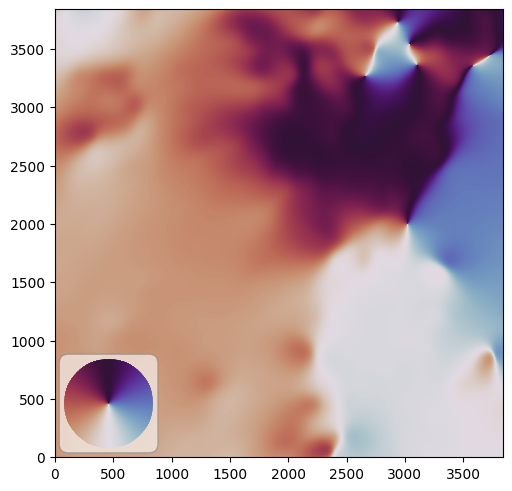

In [22]:
angle_between_b_and_fibril_test, angle_b_fibril_vals_test = calc_sep_angle_dist(bx_extra_test, by_extra_test, bz_extra_test,
    debug=True)

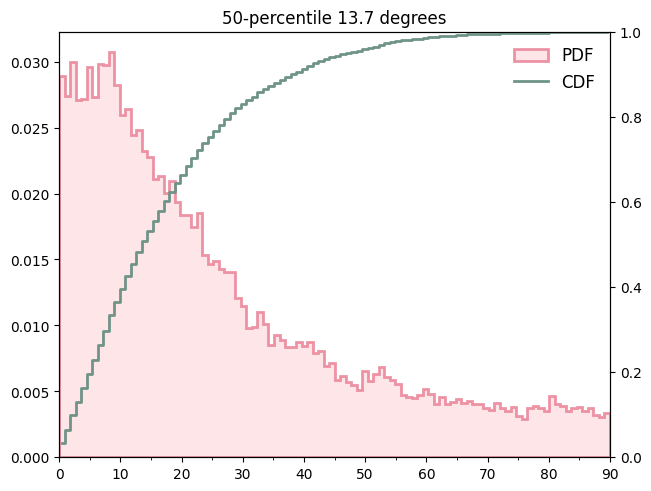

{'half_angle': np.float64(13.700478450135298),
 'angle_mean': np.float64(26.442718429936054),
 'angle_std': np.float64(22.72213203266),
 'angle_rms': np.float64(34.86420287450315)}

In [23]:
make_plot_angle_dist(angle_between_b_and_fibril_test, angle_b_fibril_vals_test)

In [14]:
def make_extrapolation_and_calc_angle_dist(
    bz,alpha,
    a=0.05,
    save_path="/cluster/home/zhuyin//Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/",
    xlim=None,
    ylim=None,
    load_path=None
    ):

    save_path = os.path.join(save_path, f"alpha_{alpha:.4f}/")
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    if load_path is not None:
        data3d = mhsxtrapy.ExtrapolationResult.load(load_path)
        bx_extra = data3d.field[:,:,:,1]
        by_extra = data3d.field[:,:,:,0]
        bz_extra = data3d.field[:,:,:,2]

        ny, nx = bz.shape

        bx_extra = bx_extra[ny:ny*2, nx:nx*2,:]
        by_extra = by_extra[ny:ny*2, nx:nx*2,:]
        bz_extra = bz_extra[ny:ny*2, nx:nx*2,:]
    else:
        bx_extra, by_extra, bz_extra= make_extrapolation(bz, alpha=alpha,a=a,return_full_res=False,save_dir=save_path)
    angle_between_b_and_fibril, angle_b_fibril_vals = calc_sep_angle_dist(bx_extra, by_extra, bz_extra,
        xlim=xlim, ylim=ylim)
    
    res_dict = make_plot_angle_dist(angle_between_b_and_fibril, angle_b_fibril_vals)

    return res_dict

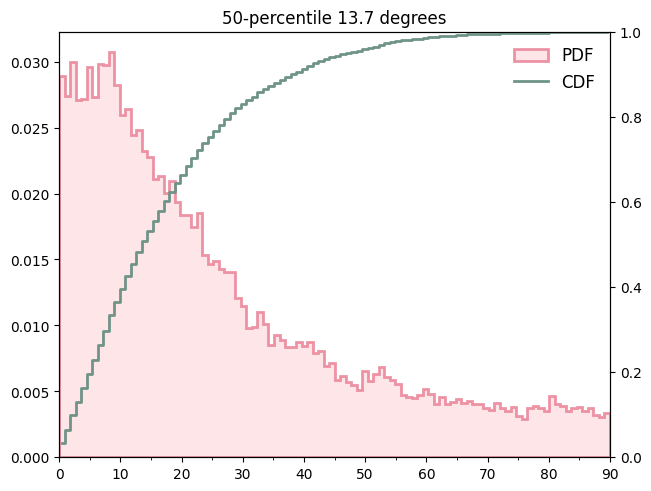

In [25]:
res_dict_alpha0 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.0
)

In [26]:
res_dict_alpha0

{'half_angle': np.float64(13.700478450135298),
 'angle_mean': np.float64(26.442718429936054),
 'angle_std': np.float64(22.72213203266),
 'angle_rms': np.float64(34.86420287450315)}

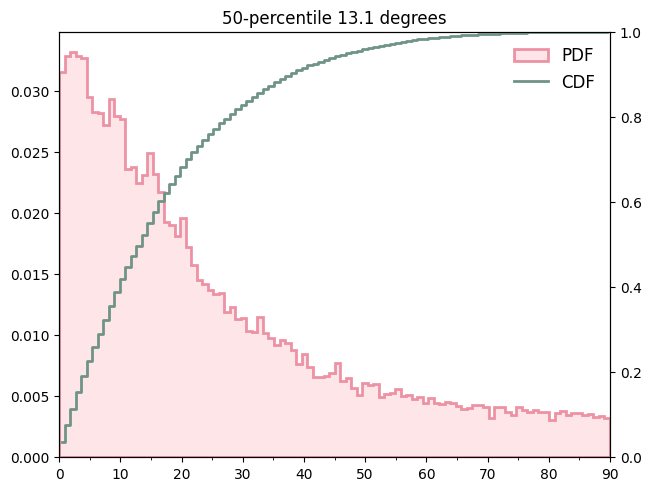

In [27]:
res_dict_alpha01 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.01,
)

In [28]:
res_dict_alpha01

{'half_angle': np.float64(13.134630189716797),
 'angle_mean': np.float64(26.046808208668413),
 'angle_std': np.float64(22.90696871106465),
 'angle_rms': np.float64(34.68667515615833)}

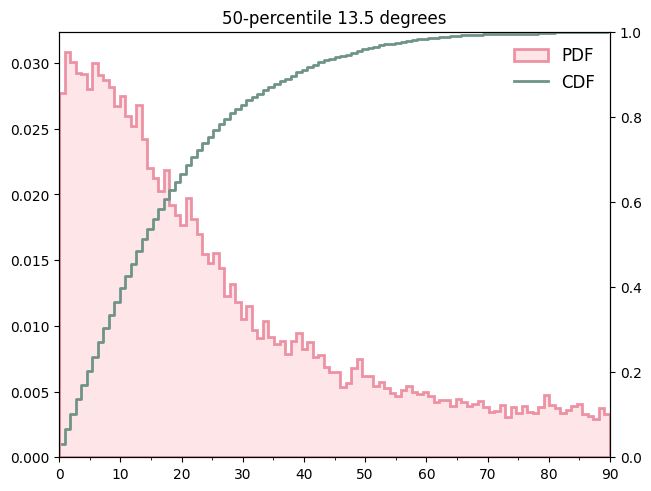

In [29]:
res_dict_alpha002 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.002,
)

In [30]:
res_dict_alpha002

{'half_angle': np.float64(13.525297840655243),
 'angle_mean': np.float64(26.296020486437286),
 'angle_std': np.float64(22.746259696299855),
 'angle_rms': np.float64(34.768851341317635)}

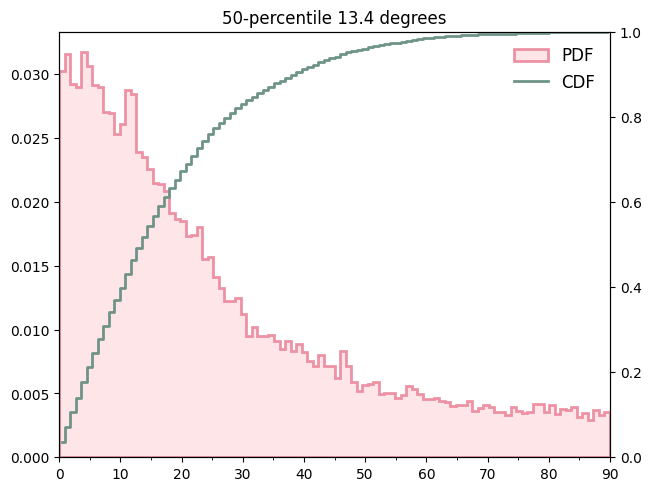

In [31]:
res_dict_alpha004 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.004,
)

In [32]:
res_dict_alpha004

{'half_angle': np.float64(13.35366528354079),
 'angle_mean': np.float64(26.1774215255322),
 'angle_std': np.float64(22.78166371900907),
 'angle_rms': np.float64(34.70247252763714)}

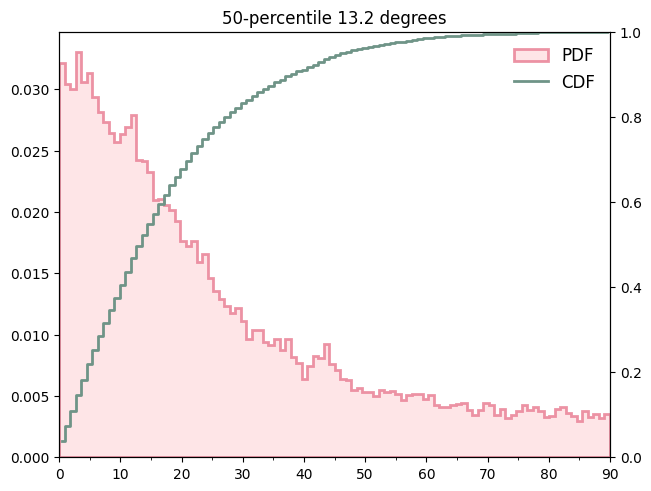

In [33]:
res_dict_alpha006 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.006,
)

In [34]:
res_dict_alpha006

{'half_angle': np.float64(13.205034949351479),
 'angle_mean': np.float64(26.091443903210106),
 'angle_std': np.float64(22.818343919260325),
 'angle_rms': np.float64(34.661798340132385)}

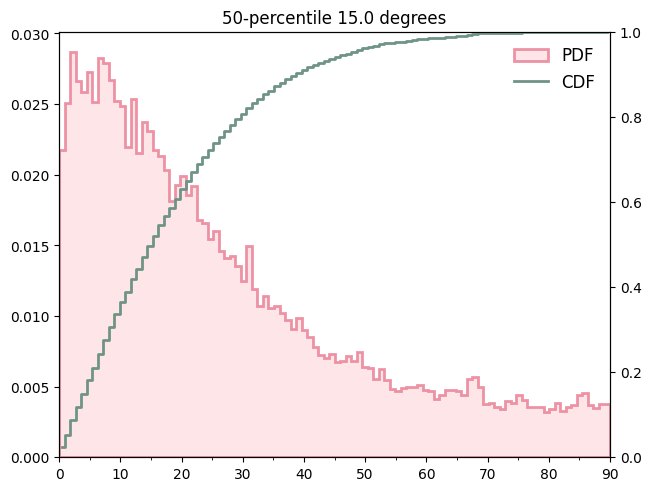

In [35]:
res_dict_alpha_minus001 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=-0.01,
)

In [36]:
res_dict_alpha_minus001

{'half_angle': np.float64(14.982801479442623),
 'angle_mean': np.float64(27.598991358657326),
 'angle_std': np.float64(22.80007942262484),
 'angle_rms': np.float64(35.79871430223777)}

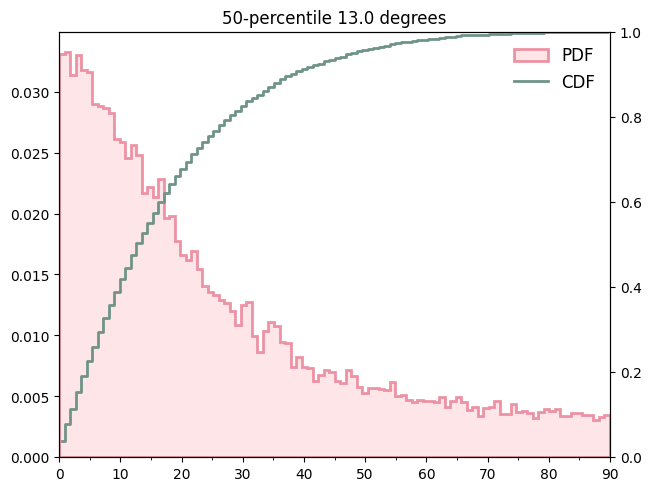

In [20]:
res_dict_alpha012 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.012,
)

In [25]:
res_dict_alpha012

{'half_angle': np.float64(12.97108002602472),
 'angle_mean': np.float64(26.09186297437929),
 'angle_std': np.float64(22.96071414228177),
 'angle_rms': np.float64(34.75600246572328)}

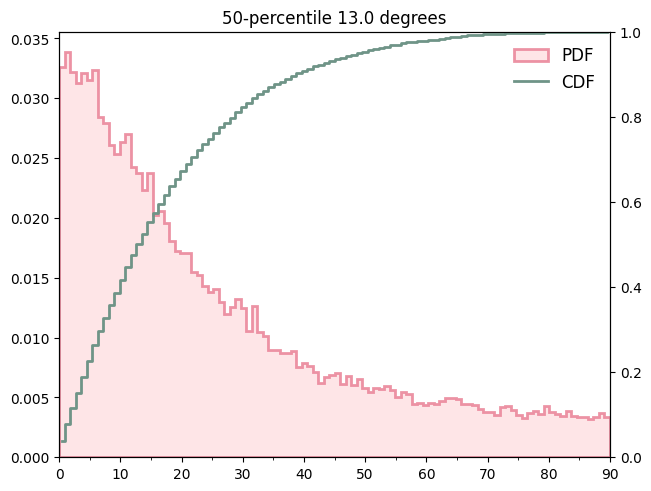

In [21]:
res_dict_alpha014 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.014,
)

In [26]:
res_dict_alpha014

{'half_angle': np.float64(13.021843995894628),
 'angle_mean': np.float64(26.187402728027234),
 'angle_std': np.float64(23.018410931485132),
 'angle_rms': np.float64(34.86584723551978)}

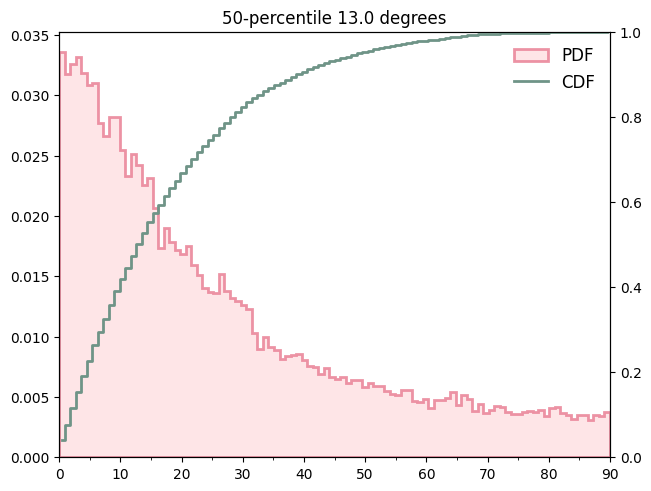

In [23]:
res_dict_alpha016 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.016,
)

In [27]:
res_dict_alpha016

{'half_angle': np.float64(13.020544600588966),
 'angle_mean': np.float64(26.331413492994216),
 'angle_std': np.float64(23.078814077667637),
 'angle_rms': np.float64(35.01392574063337)}

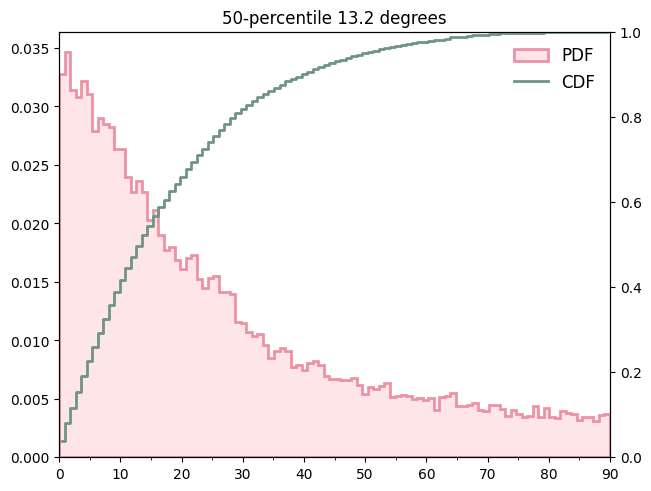

In [24]:
res_dict_alpha018 =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.018,
)

In [28]:
res_dict_alpha018

{'half_angle': np.float64(13.188156465048891),
 'angle_mean': np.float64(26.52712370976823),
 'angle_std': np.float64(23.139555298663883),
 'angle_rms': np.float64(35.20124020163596)}

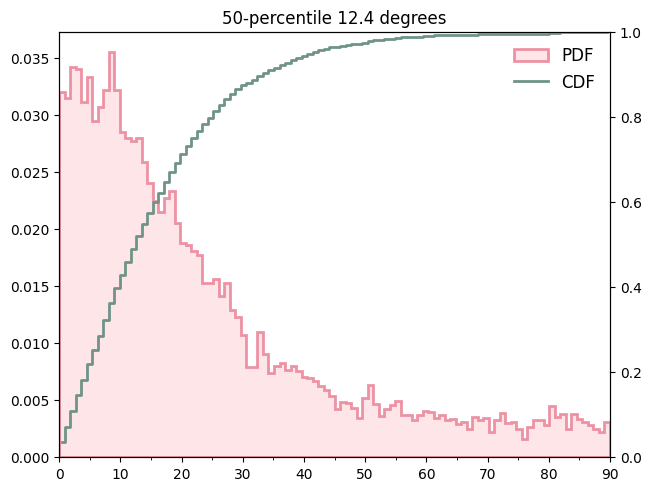

In [40]:
res_dict_alpha0_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.0,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0000/field3d.h5"
)

In [41]:
res_dict_alpha0_crop

{'half_angle': np.float64(12.441090575620766),
 'angle_mean': np.float64(23.715328549835277),
 'angle_std': np.float64(21.585947195647687),
 'angle_rms': np.float64(32.06820737989454)}

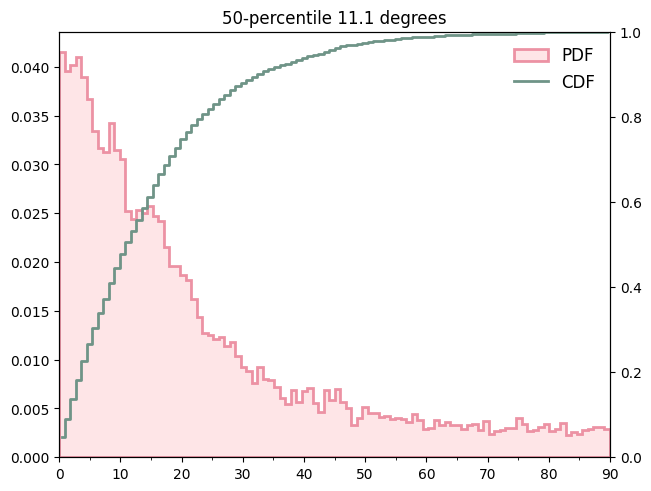

In [42]:
res_dict_alpha01_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.01,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0100/field3d.h5"
)

In [44]:
res_dict_alpha01_crop

{'half_angle': np.float64(11.080560791705938),
 'angle_mean': np.float64(22.649560272424978),
 'angle_std': np.float64(21.75663340197046),
 'angle_rms': np.float64(31.40626812472231)}

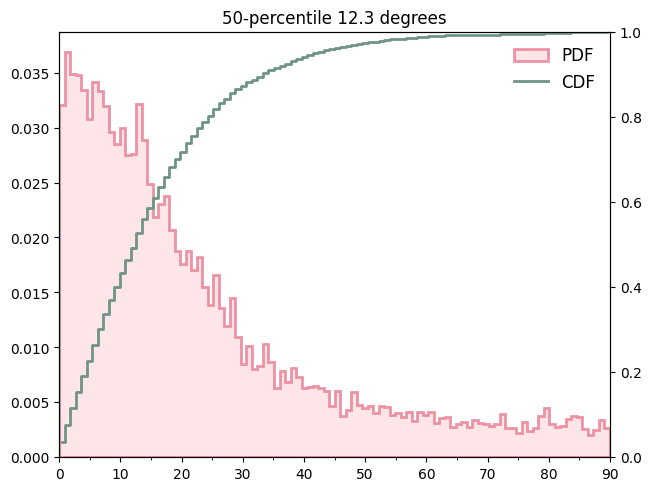

In [43]:
res_dict_alpha002_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.002,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0020/field3d.h5"
)

In [45]:
res_dict_alpha002_crop

{'half_angle': np.float64(12.343096611391497),
 'angle_mean': np.float64(23.43183933522815),
 'angle_std': np.float64(21.613136978226585),
 'angle_rms': np.float64(31.87755926465404)}

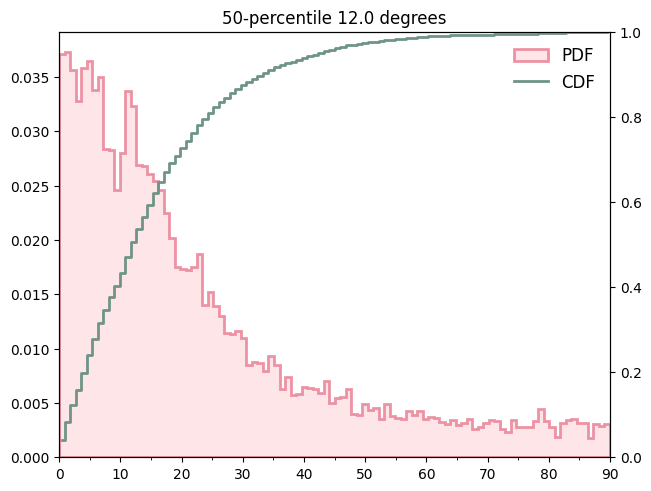

In [46]:
res_dict_alpha004_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.004,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0040/field3d.h5"
)

In [48]:
res_dict_alpha004_crop

{'half_angle': np.float64(11.977468233609738),
 'angle_mean': np.float64(23.17782410943892),
 'angle_std': np.float64(21.649204205548983),
 'angle_rms': np.float64(31.715919869706564)}

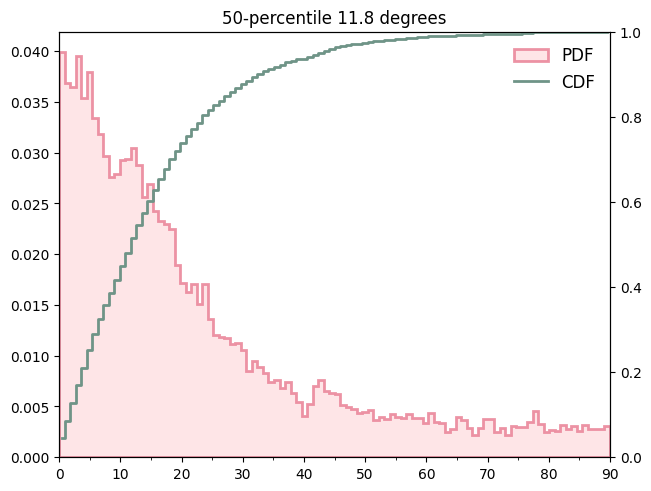

In [47]:
res_dict_alpha006_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.006,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0060/field3d.h5"
)

In [49]:
res_dict_alpha006_crop

{'half_angle': np.float64(11.75999236738328),
 'angle_mean': np.float64(22.961278864718018),
 'angle_std': np.float64(21.68689835183736),
 'angle_rms': np.float64(31.583886512370075)}

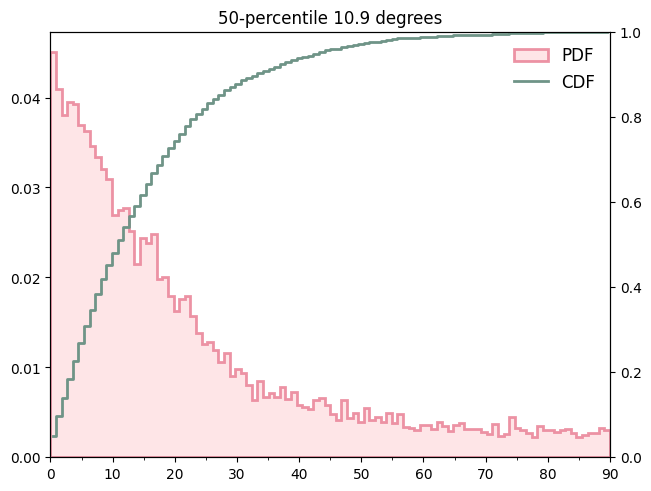

In [50]:
res_dict_alpha012_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.012,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0120/field3d.h5"
)

In [51]:
res_dict_alpha012_crop

{'half_angle': np.float64(10.927346416382255),
 'angle_mean': np.float64(22.561079474424453),
 'angle_std': np.float64(21.789635676260747),
 'angle_rms': np.float64(31.36543527444616)}

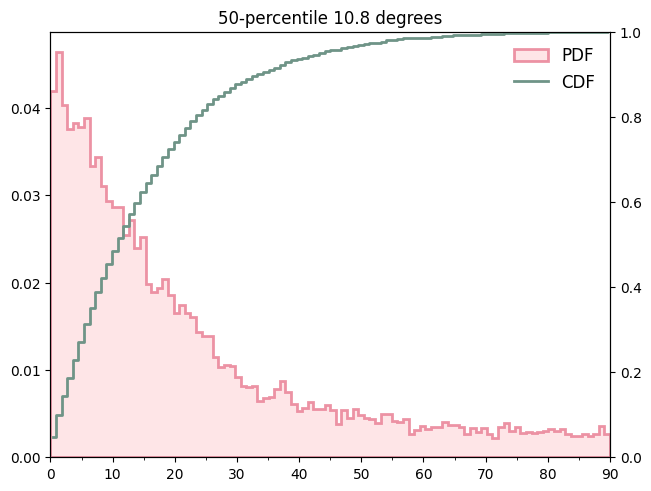

In [52]:
res_dict_alpha014_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.014,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0140/field3d.h5"
)

In [53]:
res_dict_alpha014_crop

{'half_angle': np.float64(10.79951060358891),
 'angle_mean': np.float64(22.525941710219723),
 'angle_std': np.float64(21.814519993396175),
 'angle_rms': np.float64(31.357476500421686)}

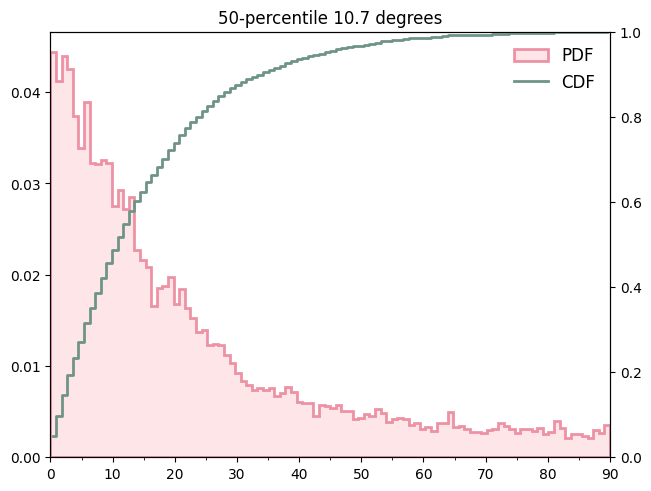

In [54]:
res_dict_alpha016_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.016,
    xlim=(500, 3500),
    ylim=(500, 2500),
    load_path="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/MHSXtra_results_new/alpha_0.0160/field3d.h5"
)

In [55]:
res_dict_alpha016_crop

{'half_angle': np.float64(10.745094264471593),
 'angle_mean': np.float64(22.545892568630034),
 'angle_std': np.float64(21.836376420349737),
 'angle_rms': np.float64(31.38701334767953)}

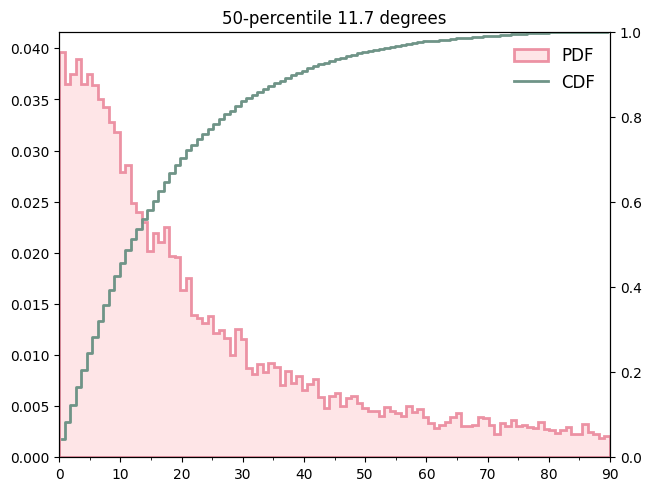

In [ ]:
res_dict_alpha02_crop =make_extrapolation_and_calc_angle_dist(
    data_bz_crop, alpha=0.02,
    xlim=(500, 3500),
    ylim=(500, 2500)
)

In [15]:
def read_vtk_to_numpy(filename):
    """
    Read VTK file and extract data as numpy arrays
    
    Parameters:
    filename: path to VTK file
    
    Returns:
    dict containing grid info and data arrays
    """
    # Read the VTK file
    mesh = pv.read(filename)
    
    # Get grid dimensions and spacing
    dimensions = mesh.dimensions
    spacing = mesh.spacing
    origin = mesh.origin
    
    print(f"Grid dimensions: {dimensions}")
    print(f"Grid spacing: {spacing}")
    print(f"Grid origin: {origin}")
    print(f"Available arrays: {list(mesh.array_names)}")
    
    # Extract all data arrays
    data_arrays = {}
    
    # Point data (most common)
    for name in mesh.point_data.keys():
        array = mesh.point_data[name]
        print(f"Point data '{name}': shape {array.shape}")
        data_arrays[f"point_{name}"] = array
    
    # Cell data
    for name in mesh.cell_data.keys():
        array = mesh.cell_data[name]
        print(f"Cell data '{name}': shape {array.shape}")
        data_arrays[f"cell_{name}"] = array
    
    return {
        'dimensions': dimensions,
        'spacing': spacing,
        'origin': origin,
        'data': data_arrays,
        'mesh': mesh  # Keep reference to original mesh
    }

def reshape_to_3d_grid(flat_array, dimensions):
    """
    Reshape flat array back to 3D grid format
    
    Parameters:
    flat_array: 1D or 2D numpy array from VTK
    dimensions: tuple of (nx, ny, nz)
    
    Returns:
    reshaped array
    """
    nx, ny, nz = dimensions
    
    if flat_array.ndim == 1:
        # Scalar field
        return flat_array.reshape((nz, ny, nx)).transpose(2, 1, 0)
    elif flat_array.ndim == 2 and flat_array.shape[1] == 3:
        # Vector field
        reshaped = flat_array.reshape((nz, ny, nx, 3)).transpose(2, 1, 0, 3)
        return reshaped
    else:
        # General case
        return flat_array.reshape((nz, ny, nx, -1)).transpose(2, 1, 0, 3)

def read_vector_field_from_vtk(filename, vector_name="B"):
    """
    Read vector field from VTK file and return as (nx, ny, nz, 3) array
    
    Parameters:
    filename: path to VTK file
    vector_name: name of the vector field in the VTK file
    
    Returns:
    numpy array of shape (nx, ny, nz, 3)
    """
    vtk_data = read_vtk_to_numpy(filename)
    
    # Look for the vector field
    vector_key = f"point_{vector_name}"
    if vector_key not in vtk_data['data']:
        available = [k for k in vtk_data['data'].keys() if 'point_' in k]
        raise ValueError(f"Vector field '{vector_name}' not found. Available: {available}")
    
    vectors_flat = vtk_data['data'][vector_key]
    dimensions = vtk_data['dimensions']
    
    # Reshape to 3D grid
    vector_array = reshape_to_3d_grid(vectors_flat, dimensions)
    
    return vector_array, vtk_data

In [16]:
bxyz_nlfff, info = read_vector_field_from_vtk(
"/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP_fullfov/bxyz_B_0002_0032.vtk",
"B"
)

bx_nlfff, by_nlfff, bz_nlfff = bxyz_nlfff[:,:,:,0], bxyz_nlfff[:,:,:,1], bxyz_nlfff[:,:,:,2]

Grid dimensions: (960, 536, 536)
Grid spacing: (1.0, 1.0, 1.0)
Grid origin: (0.0, 0.0, 0.0)
Available arrays: ['B']
Point data 'B': shape (275804160, 3)


In [17]:
bx_nlfff.shape

(960, 536, 536)

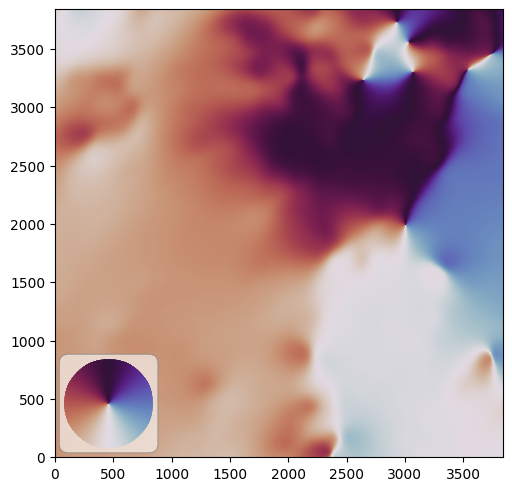

In [18]:
angle_between_b_and_fibril_nlfff, angle_b_fibril_vals_nlfff = calc_sep_angle_dist(
    bx_nlfff.transpose(1,0,2),
    by_nlfff.transpose(1,0,2),
    bz_nlfff.transpose(1,0,2),
    debug=True, height_index=4)

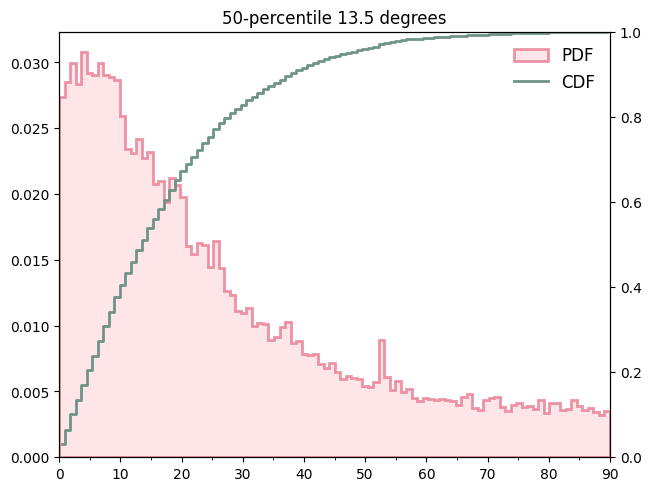

In [19]:
res_dict_nlfff = make_plot_angle_dist(angle_between_b_and_fibril_nlfff, angle_b_fibril_vals_nlfff)

In [20]:
res_dict_nlfff

{'half_angle': np.float64(13.545991253644313),
 'angle_mean': np.float64(26.712129571287758),
 'angle_std': np.float64(23.005830557276084),
 'angle_rms': np.float64(35.25345523297488)}